### Problem Statement

### Objectives

### Import Libraires

In [72]:
# Basic Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Basic Checks

#### Load Dataset

In [73]:
sheets = pd.read_excel("C:/Users/Admin/Documents/GitHub/Sales-Analytics-Dashboard/Dataset/Regional Sales Dataset.xlsx", sheet_name = None)
sheets

{'Sales Orders':         OrderNumber  OrderDate  Customer Name Index      Channel  \
 0       SO - 000225 2014-01-01                  126    Wholesale   
 1      SO - 0003378 2014-01-01                   96  Distributor   
 2      SO - 0005126 2014-01-01                    8    Wholesale   
 3      SO - 0005614 2014-01-01                   42       Export   
 4      SO - 0005781 2014-01-01                   73    Wholesale   
 ...             ...        ...                  ...          ...   
 64099  SO - 0007573 2018-02-28                   74    Wholesale   
 64100  SO - 0007706 2018-02-28                   51       Export   
 64101  SO - 0007718 2018-02-28                  136  Distributor   
 64102  SO - 0008084 2018-02-28                  158  Distributor   
 64103  SO - 0008654 2018-02-28                   22  Distributor   
 
       Currency Code Warehouse Code  Delivery Region Index  \
 0               USD         AXW291                    364   
 1               USD         A

In [74]:
sales_sheet = sheets['Sales Orders']
customer_sheet = sheets['Customers']
region_sheet = sheets['Regions']
state_regions_sheet = sheets['State Regions']
product_sheet = sheets['Products']
budget_sheet = sheets['2017 Budgets'] 

In [75]:
sales_sheet.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [76]:
customer_sheet.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [77]:
region_sheet.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [78]:
state_regions_sheet.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [79]:
new_header = state_regions_sheet.iloc[0]
state_regions_sheet.columns = new_header
state_regions_sheet = state_regions_sheet[1:].reset_index(drop=True)

In [80]:
state_regions_sheet.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [81]:
product_sheet.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [82]:
budget_sheet.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [83]:
# Shape
print("Sales Sheet Shape :", sales_sheet.shape)
print("Customer Sheet Shape :", customer_sheet.shape)
print("Region Sheet Shape :", region_sheet.shape)
print("State Regions Sheet Shape :", state_regions_sheet.shape)
print("Product Sheet Shape :", product_sheet.shape)
print("Budget Sheet Shape :", budget_sheet.shape)

Sales Sheet Shape : (64104, 12)
Customer Sheet Shape : (175, 2)
Region Sheet Shape : (994, 15)
State Regions Sheet Shape : (48, 3)
Product Sheet Shape : (30, 2)
Budget Sheet Shape : (30, 2)


In [84]:
# Null Values Check
sales_sheet.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [85]:
customer_sheet.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [86]:
region_sheet.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [87]:
state_regions_sheet.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [88]:
product_sheet.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [89]:
budget_sheet.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

### Data Cleaning and Wrangling

#### Merge all tables to Sales Table

In [90]:
# Merge with Customer

merge_data = sales_sheet.merge(
    customer_sheet,
    how='left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index'
)

In [91]:
merge_data.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [92]:
# Merge with Products

merge_data = merge_data.merge(
    product_sheet,
    how='left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)

In [93]:
merge_data.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [94]:
# Merge with Region

merge_data = merge_data.merge(
    region_sheet,
    how='left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
) 

In [95]:
merge_data.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [96]:
# Merge with State Region

merge_data = merge_data.merge(
    state_regions_sheet[['State Code', 'Region']],
    how='left',
    left_on = 'state_code',
    right_on = 'State Code'
)

In [97]:
merge_data.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [98]:
# Merge with Budgets

merge_data = merge_data.merge(
    budget_sheet,
    how='left',
    on = 'Product Name'
) 

In [99]:
merge_data.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'State Code', 'Region', '2017 Budgets'],
      dtype='object')

In [100]:
# Remove Duplicate Columns

# Customer Index
# Index
# id
# State Code 

drop_columns = ['Customer Index','Index','id','State Code']
merge_data = merge_data.drop(columns = drop_columns)

In [101]:
merge_data.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Names', 'Product Name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'Region', '2017 Budgets'],
      dtype='object')

#### Columns are Lower Case

In [102]:
merge_data.columns = merge_data.columns.str.lower()

In [103]:
merge_data.columns

Index(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'region', '2017 budgets'],
      dtype='object')

In [104]:
merge_data.head(1)

,ordernumber,orderdate,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order quantity,unit price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,region,2017 budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231


In [105]:
# Keep Necessary Columns Only

cols_to_keep = [
    'ordernumber', 
    'orderdate',
    'channel',
    'currency code', 
    'warehouse code',
    'order quantity', 
    'unit price',
    'line total', 
    'total unit cost', 
    'customer names', 
    'product name',
    'name', 
    'county', 
    'state_code', 
    'state',
    'latitude',
    'longitude',
    'region', 
    '2017 budgets'
] 

In [106]:
merge_data = merge_data[cols_to_keep]
merge_data.head()

,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,line total,total unit cost,customer names,product name,name,county,state_code,state,latitude,longitude,region,2017 budgets
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Savannah,Chatham County,GA,Georgia,32.08354,-81.09983,South,964940.231
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Greenwood,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,2067108.120
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,Pleasanton,Alameda County,CA,California,37.66243,-121.87468,West,5685138.270
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,Bloomington,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,889737.555
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,Manchester,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,1085037.329


In [107]:
merge_data.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'line total',
       'total unit cost', 'customer names', 'product name', 'name', 'county',
       'state_code', 'state', 'latitude', 'longitude', 'region',
       '2017 budgets'],
      dtype='object')

In [108]:
merge_data = merge_data.rename(columns= {
   'ordernumber':'order_number',
    'orderdate':'order_date',
    'currency code':'currency_code',
    'warehouse code':'warehouse_code',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total' : 'revenue',
    'total unit cost':'total_unit_cost',
    'customer names': 'customer_names',
    'product name':'product_name',
    'latitude':'lat',
    'longitude':'log',
    '2017 budgets' : 'budgets'
})
                                                 

In [109]:
merge_data.columns

Index(['order_number', 'order_date', 'channel', 'currency_code',
       'warehouse_code', 'order_quantity', 'unit_price', 'revenue',
       'total_unit_cost', 'customer_names', 'product_name', 'name', 'county',
       'state_code', 'state', 'lat', 'log', 'region', 'budgets'],
      dtype='object')

In [110]:
merge_data.head(1)

,order_number,order_date,channel,currency_code,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,product_name,name,county,state_code,state,lat,log,region,budgets
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Savannah,Chatham County,GA,Georgia,32.08354,-81.09983,South,964940.231


#### In our Dataset, we have only 2017 Budget column for all input datas but, we need 2014 - 2018 Budget data. so seperate the 2017 budgets only.

In [111]:
# Blank out budgets for non-2017 data
merge_data.loc[merge_data['order_date'].dt.year != 2017, 'budgets'] = pd.NA

merge_data[['order_date', 'product_name', 'revenue', 'budgets']]

,order_date,product_name,revenue,budgets
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
...,...,...,...,...
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN


In [112]:
merge_data.head()

,order_number,order_date,channel,currency_code,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,product_name,name,county,state_code,state,lat,log,region,budgets
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Savannah,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Greenwood,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,Pleasanton,Alameda County,CA,California,37.66243,-121.87468,West,NaN
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,Bloomington,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,Manchester,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN


In [113]:
merge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   channel          64104 non-null  object        
 3   currency_code    64104 non-null  object        
 4   warehouse_code   64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total_unit_cost  64104 non-null  float64       
 9   customer_names   64104 non-null  object        
 10  product_name     64104 non-null  object        
 11  name             64104 non-null  object        
 12  county           64104 non-null  object        
 13  state_code       64104 non-null  object        
 14  state            64104 non-null  objec

In [114]:
# Check Missing Values
merge_data.isnull().sum()

order_number           0
order_date             0
channel                0
currency_code          0
warehouse_code         0
order_quantity         0
unit_price             0
revenue                0
total_unit_cost        0
customer_names         0
product_name           0
name                   0
county                 0
state_code             0
state                  0
lat                    0
log                    0
region                 0
budgets            48841
dtype: int64

In [115]:
merge_data.describe()

,order_date,order_quantity,unit_price,revenue,total_unit_cost,lat,log,budgets
count,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,1.526300e+04
mean,2016-01-29 01:28:20.935979008,8.441689,2284.380803,19280.682937,1432.083899,37.769427,-94.247116,2.989305e+06
min,2014-01-01 00:00:00,5.000000,167.500000,837.500000,68.675000,25.468720,-123.262040,5.944716e+05
25%,2015-01-13 00:00:00,6.000000,1031.800000,8019.900000,606.216000,33.953330,-112.034140,1.672229e+06
50%,2016-01-27 00:00:00,8.000000,1855.900000,14023.100000,1084.495500,39.114170,-88.200900,3.016489e+06
75%,2017-02-13 00:00:00,10.000000,3606.275000,27416.400000,2046.933750,41.676550,-80.407000,3.925425e+06
max,2018-02-28 00:00:00,12.000000,6566.000000,78711.600000,5498.556000,48.759550,-70.255330,5.685138e+06
std,NaN,2.276217,1663.598141,15429.602766,1107.705728,5.068599,16.884334,1.557271e+06


In [116]:
merge_data.duplicated().sum()

np.int64(0)

In [117]:
merge_data.dtypes

order_number               object
order_date         datetime64[ns]
channel                    object
currency_code              object
warehouse_code             object
order_quantity              int64
unit_price                float64
revenue                   float64
total_unit_cost           float64
customer_names             object
product_name               object
name                       object
county                     object
state_code                 object
state                      object
lat                       float64
log                       float64
region                     object
budgets                   float64
dtype: object

In [118]:
merge_data.describe()

,order_date,order_quantity,unit_price,revenue,total_unit_cost,lat,log,budgets
count,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,1.526300e+04
mean,2016-01-29 01:28:20.935979008,8.441689,2284.380803,19280.682937,1432.083899,37.769427,-94.247116,2.989305e+06
min,2014-01-01 00:00:00,5.000000,167.500000,837.500000,68.675000,25.468720,-123.262040,5.944716e+05
25%,2015-01-13 00:00:00,6.000000,1031.800000,8019.900000,606.216000,33.953330,-112.034140,1.672229e+06
50%,2016-01-27 00:00:00,8.000000,1855.900000,14023.100000,1084.495500,39.114170,-88.200900,3.016489e+06
75%,2017-02-13 00:00:00,10.000000,3606.275000,27416.400000,2046.933750,41.676550,-80.407000,3.925425e+06
max,2018-02-28 00:00:00,12.000000,6566.000000,78711.600000,5498.556000,48.759550,-70.255330,5.685138e+06
std,NaN,2.276217,1663.598141,15429.602766,1107.705728,5.068599,16.884334,1.557271e+06


In [119]:
merge_data['Year'] = merge_data['order_date'].dt.year
merge_data['Month'] = merge_data['order_date'].dt.month_name()
merge_data['Quarter'] = merge_data['order_date'].dt.quarter

In [120]:
merge_data.head()

,order_number,order_date,channel,currency_code,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,...,county,state_code,state,lat,log,region,budgets,Year,Month,Quarter
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,...,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN,2014,January,1
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,...,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN,2014,January,1
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,...,Alameda County,CA,California,37.66243,-121.87468,West,NaN,2014,January,1
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,...,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN,2014,January,1
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,...,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN,2014,January,1


### Feature Engineering

In [123]:
merge_data['total_cost'] = merge_data['order_quantity'] * merge_data['total_unit_cost'] 

In [124]:
merge_data['profit'] = merge_data['revenue'] - merge_data['total_cost']

merge_data['profit_margin_pct'] = merge_data['profit'] / merge_data['revenue'] * 100 

In [125]:
merge_data.head()

,order_number,order_date,channel,currency_code,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,...,lat,log,region,budgets,Year,Month,Quarter,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,...,32.08354,-81.09983,South,NaN,2014,January,1,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,...,39.61366,-86.10665,Midwest,NaN,2014,January,1,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,...,37.66243,-121.87468,West,NaN,2014,January,1,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,...,39.16533,-86.52639,Midwest,NaN,2014,January,1,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,...,41.77524,-72.52443,Northeast,NaN,2014,January,1,10082.160,8249.040,45.0


### Exploratory Data Analysis

 #### 1. Monthly Sales Trend Over Time

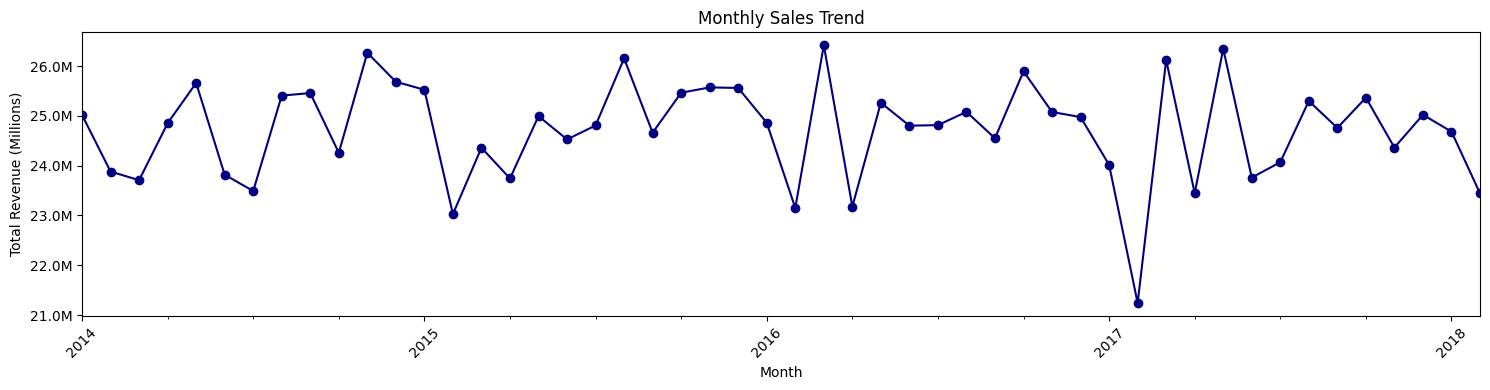

In [133]:
merge_data['order_month'] = merge_data['order_date'].dt.to_period('M')

monthly_sales = merge_data.groupby('order_month')['revenue'].sum()

plt.figure(figsize = (15,4))

monthly_sales.plot(marker = 'o', color = 'navy')

from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show() 

####  2. Monthly Sales Trend

In [143]:
merge_data.head(1)

,order_number,order_date,channel,currency_code,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,...,log,region,budgets,Year,Month,Quarter,total_cost,profit,profit_margin_pct,order_month
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,...,-81.09983,South,NaN,2014,January,1,10946.058,4048.542,27.0,2014-01


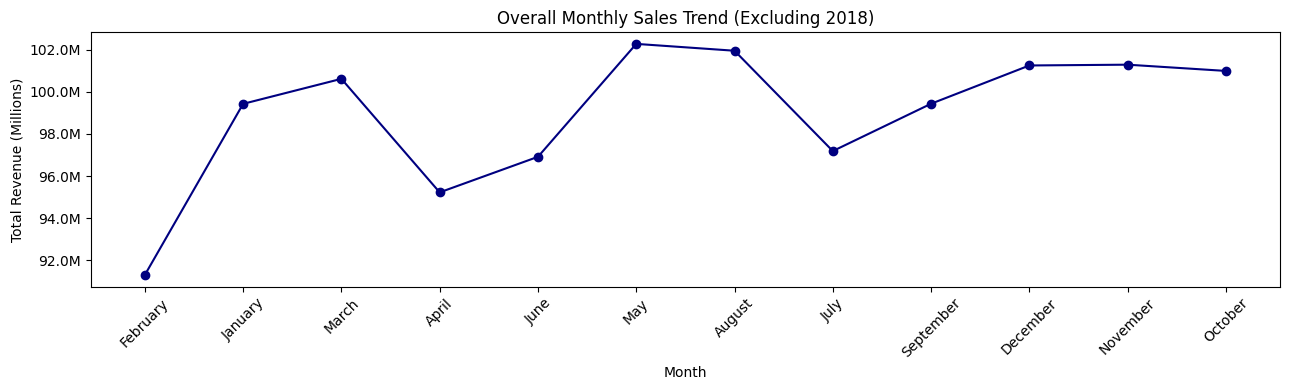

In [147]:

# 1. Filter out any 2018 orders
# exclude any partial-year data (i.e., January and February of 2018) so that the monthly totals aren’t skewed by an incomplete year.
merge_data_ = merge_data[merge_data['order_date'].dt.year != 2018]   # I create merge_data_ so I don’t alter the original merge_data, preserving it intact for other analyses while filtering just for this chart.


# 2. Group by Quarter and Month, sum revenue, then sort by month number
# Quarter refers to Order date
# Month refers to Order Month
monthly_sales = (
    merge_data_
    .groupby(['Quarter', 'Month'])['revenue']
    .sum()
    .sort_index()
)

# 3. Plot setup
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values('Month'),  
    monthly_sales.values,                     
    marker='o',                               
    color='navy'                              
)

# 4. Scale y-axis values to millions for readability
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 5. Add title and axis labels
plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show() 

#### 3. Top 10 Product By Revenue (in Million)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3184\2744217383.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


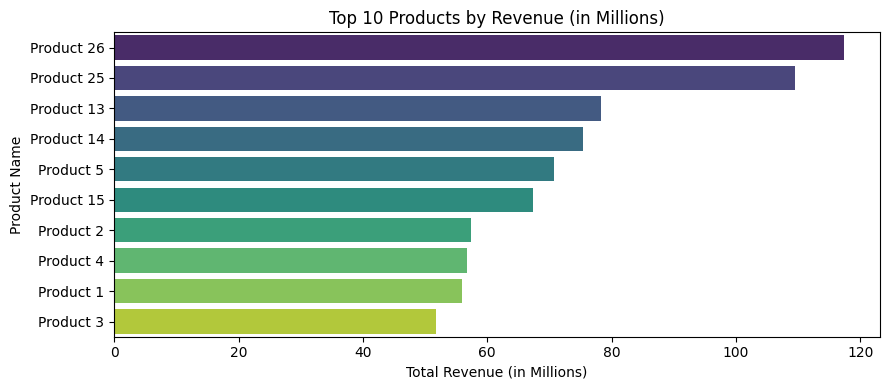

In [140]:
# Calculate total revenue for each product and convert values to millions
top_prod = merge_data.groupby('product_name')['revenue'].sum() / 1_000_000

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,    # X-axis: revenue values in millions
    y=top_prod.index,     # Y-axis: product names
    palette='viridis'     # Color palette for bars
)

plt.title('Top 10 Products by Revenue (in Millions)') 
plt.xlabel('Total Revenue (in Millions)')           
plt.ylabel('Product Name')                            

plt.tight_layout()

plt.show()

#### 4. Sales by Channel (Pie Chart)

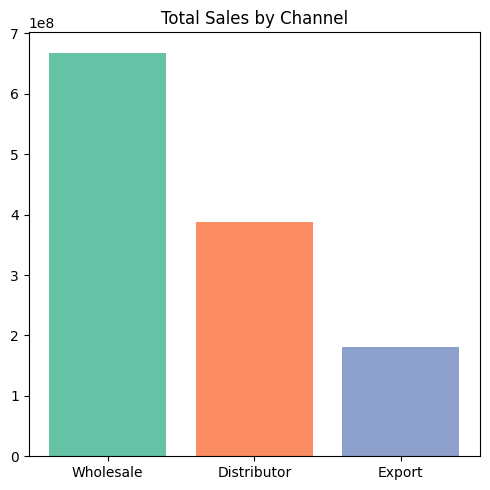

In [154]:
# Group revenue by sales channel and sort descending
chan_sales = merge_data.groupby('channel')['revenue'].sum().sort_values(ascending=False)

colors = plt.cm.Set2.colors

# Set figure size for the pie chart
plt.figure(figsize=(5, 5))

# Plot pie chart with percentage labels and a defined start angle
plt.bar(
    chan_sales.index,
    chan_sales.values,
    color=colors
)
# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

#### 5. Top 10 States by Revenue

In [158]:
merge_data.columns

Index(['order_number', 'order_date', 'channel', 'currency_code',
       'warehouse_code', 'order_quantity', 'unit_price', 'revenue',
       'total_unit_cost', 'customer_names', 'product_name', 'name', 'county',
       'state_code', 'state', 'lat', 'log', 'region', 'budgets', 'Year',
       'Month', 'Quarter', 'total_cost', 'profit', 'profit_margin_pct',
       'order_month'],
      dtype='object')

In [163]:
state_rev = merge_data.groupby('state').agg(
    revenue=('revenue', 'sum'),         
    orders=('order_number', 'nunique')   
).sort_values('revenue', ascending=False).head(10)  

colors = plt.cm.Set2.colors

C:\Users\Admin\AppData\Local\Temp\ipykernel_3184\4134833410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


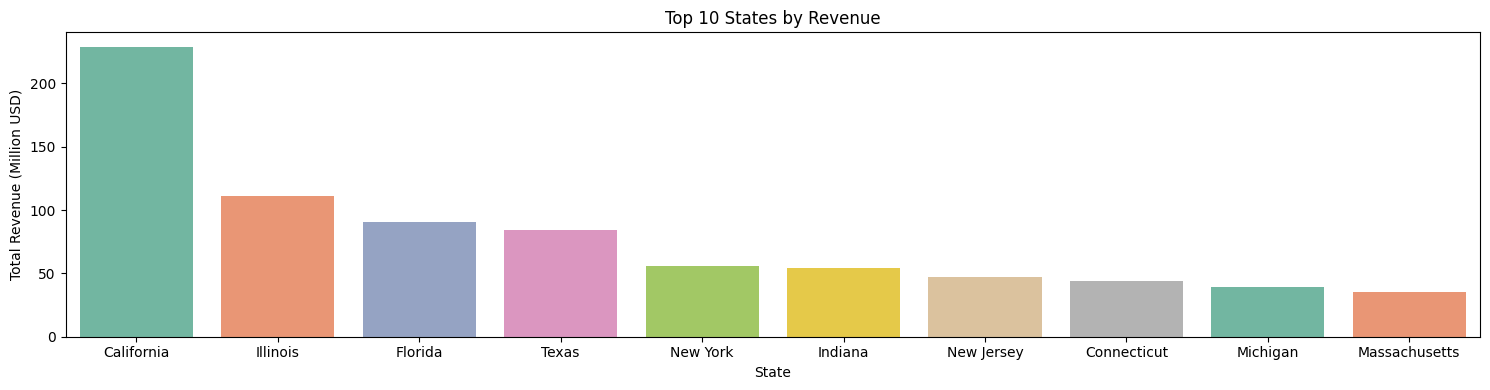

In [164]:
plt.figure(figsize=(15, 4))

sns.barplot(
    x=state_rev.index,                   
    y=state_rev['revenue'] / 1e6,      
    palette= colors                
)

plt.title('Top 10 States by Revenue')   
plt.xlabel('State')                       
plt.ylabel('Total Revenue (Million USD)') 

plt.tight_layout()  

plt.show()                             


#### 6. Top 10 States by Order Count

C:\Users\Admin\AppData\Local\Temp\ipykernel_3184\3723365245.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


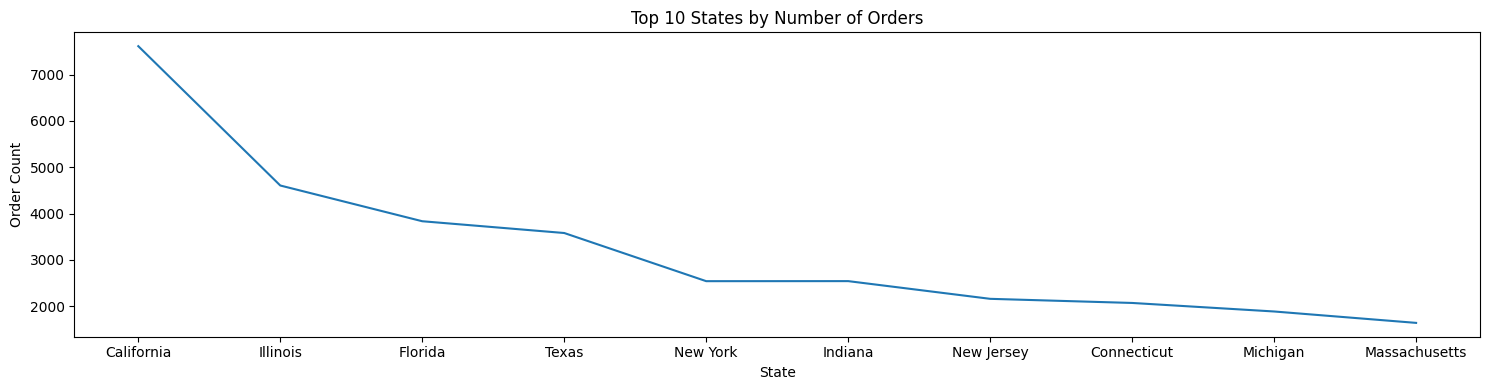

In [168]:
plt.figure(figsize=(15, 4))

sns.lineplot(
    x=state_rev.index,                  
    y=state_rev['orders'],          
    palette= 'coolwarm'            
)

plt.title('Top 10 States by Number of Orders')  
plt.xlabel('State')                             
plt.ylabel('Order Count')   

plt.tight_layout()   

plt.show()                                       

#### 7. Correlation Heatmap of Numeric Features

In [171]:
merge_data.columns

Index(['order_number', 'order_date', 'channel', 'currency_code',
       'warehouse_code', 'order_quantity', 'unit_price', 'revenue',
       'total_unit_cost', 'customer_names', 'product_name', 'name', 'county',
       'state_code', 'state', 'lat', 'log', 'region', 'budgets', 'Year',
       'Month', 'Quarter', 'total_cost', 'profit', 'profit_margin_pct',
       'order_month'],
      dtype='object')

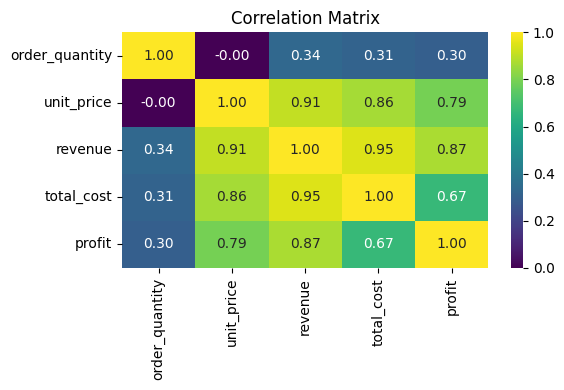

In [172]:
num_cols = ['order_quantity', 'unit_price', 'revenue', 'total_cost', 'profit']

corr = merge_data[num_cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,           
    annot=True,     
    fmt=".2f",     
    cmap='viridis'  
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()  

In [174]:
# Export Final DataFrame to CSV
merge_data.to_csv('Sales_data.csv', index=False)